In [1]:
import pickle
import numpy as np
import pandas as pd

In [ ]:
with open('../data/processed/subject_01/night_1/aligned_data.pkl', 'rb') as f:
    aligned_data = pickle.load(f)
print(f"Loaded {len(aligned_data)} epochs")

Loaded 935 epochs


In [3]:
def extract_hr_features(hr_vals):
    if len(hr_vals) == 0:
        return {'hr_mean':0, 'hr_std':0, 'hr_min':0, 'hr_max':0, 'hr_range':0, 'hr_max':0, 'hr_range':0}
    return{
        'hr_mean':np.mean(hr_vals),
        'hr_std': np.std(hr_vals) if len(hr_vals) > 1 else 0,
        'hr_min': np.min(hr_vals),
        'hr_max': np.max(hr_vals),
        'hr_range': np.max(hr_vals) - np.min(hr_vals)
    }


In [4]:
sample_hr = aligned_data[0]['hr_readings']
print(extract_hr_features(sample_hr))

{'hr_mean': np.float64(66.85714285714286), 'hr_std': np.float64(0.989743318610787), 'hr_min': np.float64(65.0), 'hr_max': np.float64(68.0), 'hr_range': np.float64(3.0)}


In [5]:
def extract_acc_features(acc_vals):
    acc_vals = np.asarray(acc_vals)
    if len(acc_vals) == 0:
        return {col: 0 for col in [
            'acc_x_mean','acc_x_std','acc_y_mean','acc_y_std',
            'acc_z_mean','acc_z_std','acc_mag_mean','acc_mag_std',
            'acc_mag_min','acc_mag_max','acc_mag_range','acc_movement'
        ]}    
    x = acc_vals[:, 0]
    y = acc_vals[:, 1]
    z = acc_vals[:, 2]
    # overall movement intensity
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    # how much magnitude changes over time (activity level
    movement = np.std(magnitude)    
    return {
        'acc_x_mean':     np.mean(x),
        'acc_x_std':      np.std(x),
        'acc_y_mean':     np.mean(y),
        'acc_y_std':      np.std(y),
        'acc_z_mean':     np.mean(z),
        'acc_z_std':      np.std(z),
        'acc_mag_mean':   np.mean(magnitude),
        'acc_mag_std':    np.std(magnitude),
        'acc_mag_min':    np.min(magnitude),
        'acc_mag_max':    np.max(magnitude),
        'acc_mag_range':  np.max(magnitude) - np.min(magnitude),
        'acc_movement':   movement}

In [6]:
sample_acc = aligned_data[0]['acc_readings']
print(extract_acc_features(sample_acc))

{'acc_x_mean': np.float64(-0.5165099587328856), 'acc_x_std': np.float64(0.21837543817200689), 'acc_y_mean': np.float64(0.07689371268486099), 'acc_y_std': np.float64(0.5596940351541182), 'acc_z_mean': np.float64(0.06076150849511392), 'acc_z_std': np.float64(0.6180092846647305), 'acc_mag_mean': np.float64(1.0061633100174154), 'acc_mag_std': np.float64(0.08308583468821126), 'acc_mag_min': np.float64(0.6242927270954848), 'acc_mag_max': np.float64(1.9912741942996204), 'acc_mag_range': np.float64(1.3669814672041356), 'acc_movement': np.float64(0.08308583468821126)}


In [7]:
rows = []
for d in aligned_data:
    hr_featr  = extract_hr_features(d['hr_readings'])
    acc_featr = extract_acc_features(d['acc_readings'])
    
    row = {}
    row.update(hr_featr)
    row.update(acc_featr)
    row['label'] = int(d['label'])
    
    rows.append(row)

features_df = pd.DataFrame(rows)
print(features_df.shape)
print(features_df.head())

(935, 18)
     hr_mean    hr_std  hr_min  hr_max  hr_range  acc_x_mean  acc_x_std  \
0  66.857143  0.989743    65.0    68.0       3.0   -0.516510   0.218375   
1  77.000000  1.224745    76.0    79.0       3.0   -0.317128   0.199731   
2  76.666667  2.054805    74.0    79.0       5.0   -0.428147   0.485928   
3  64.857143  2.099563    63.0    68.0       5.0   -0.648261   0.152702   
4  70.000000  1.000000    69.0    71.0       2.0    0.206364   0.623881   

   acc_y_mean  acc_y_std  acc_z_mean  acc_z_std  acc_mag_mean  acc_mag_std  \
0    0.076894   0.559694    0.060762   0.618009      1.006163     0.083086   
1   -0.655067   0.405998   -0.291884   0.472577      1.014639     0.115946   
2    0.438573   0.536115   -0.193131   0.282210      1.004336     0.086323   
3    0.471713   0.539757   -0.127840   0.218416      1.006278     0.094144   
4    0.532615   0.348114   -0.022741   0.459403      1.015476     0.130584   

   acc_mag_min  acc_mag_max  acc_mag_range  acc_movement  label  
0   

In [8]:
print("NaN count per column:")
print(features_df.isnull().sum())

features_df.fillna(0, inplace=True)

print("\nAfter fillna:")
print(features_df.isnull().sum().sum(), "NaNs remaining")

NaN count per column:
hr_mean          0
hr_std           0
hr_min           0
hr_max           0
hr_range         0
acc_x_mean       0
acc_x_std        0
acc_y_mean       0
acc_y_std        0
acc_z_mean       0
acc_z_std        0
acc_mag_mean     0
acc_mag_std      0
acc_mag_min      0
acc_mag_max      0
acc_mag_range    0
acc_movement     0
label            0
dtype: int64

After fillna:
0 NaNs remaining


In [9]:
print(features_df.describe().round(3))

       hr_mean   hr_std   hr_min   hr_max  hr_range  acc_x_mean  acc_x_std  \
count  935.000  935.000  935.000  935.000   935.000     935.000    935.000   
mean    58.868    0.979   57.747   60.163     2.416      -0.125      0.012   
std      4.257    1.390    3.842    5.310     3.424       0.333      0.058   
min     50.250    0.000   49.000   51.000     0.000      -0.858      0.001   
25%     55.833    0.462   55.000   57.000     1.000      -0.224      0.001   
50%     58.500    0.632   58.000   59.000     2.000      -0.083      0.001   
75%     61.000    1.020   60.000   62.000     3.000       0.130      0.002   
max     83.400   13.853   80.000   93.000    34.000       0.464      0.692   

       acc_y_mean  acc_y_std  acc_z_mean  acc_z_std  acc_mag_mean  \
count     935.000    935.000     935.000    935.000       935.000   
mean       -0.080      0.020      -0.381      0.017         1.002   
std         0.691      0.091       0.481      0.072         0.004   
min        -0.977    

In [10]:
label_map = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}

print("Mean HR by sleep stage:")
print(features_df.groupby('label')['hr_mean'].mean().rename(label_map).round(2))

print("\nMean ACC movement by sleep stage:")
print(features_df.groupby('label')['acc_movement'].mean().rename(label_map).round(4))

Mean HR by sleep stage:
label
Wake    64.28
N1      60.68
N2      56.35
N3      59.43
REM     60.76
Name: hr_mean, dtype: float64

Mean ACC movement by sleep stage:
label
Wake    0.0666
N1      0.0144
N2      0.0031
N3      0.0015
REM     0.0038
Name: acc_movement, dtype: float64


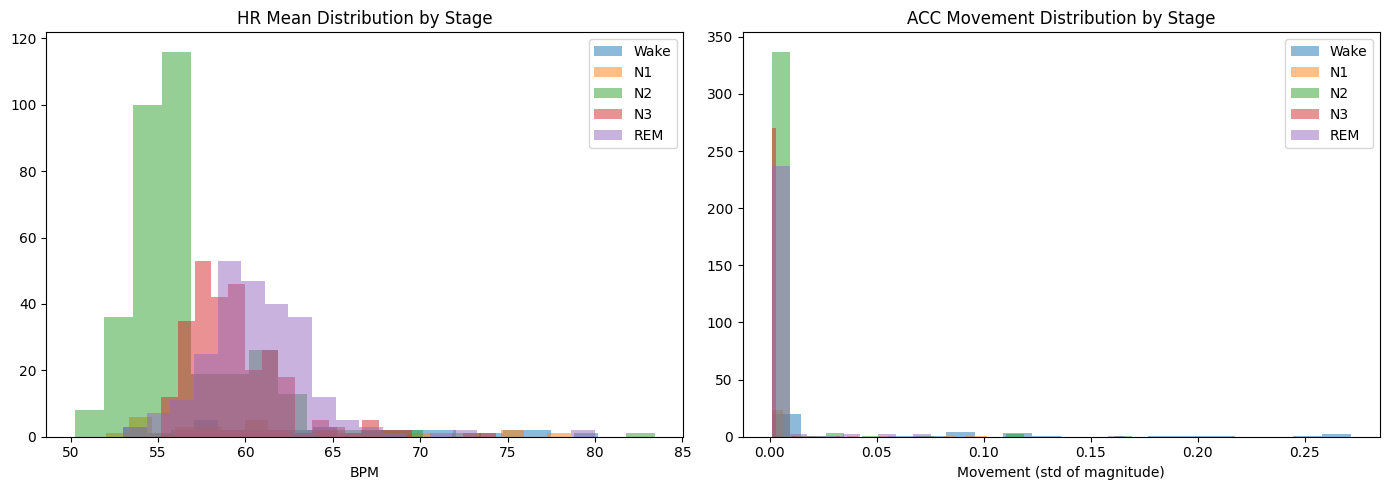

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name in label_map.items():
    subset = features_df[features_df['label'] == label]['hr_mean']
    axes[0].hist(subset, alpha=0.5, label=name, bins=20)
axes[0].set_title('HR Mean Distribution by Stage')
axes[0].set_xlabel('BPM')
axes[0].legend()

for label, name in label_map.items():
    subset = features_df[features_df['label'] == label]['acc_movement']
    axes[1].hist(subset, alpha=0.5, label=name, bins=20)
axes[1].set_title('ACC Movement Distribution by Stage')
axes[1].set_xlabel('Movement (std of magnitude)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
features_df.to_csv('../data/processed/subject_01/night_1/features.csv', index=False)
print("Saved features.csv")
print(f"Shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")

Saved features.csv
Shape: (935, 18)
Columns: ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_min', 'acc_mag_max', 'acc_mag_range', 'acc_movement', 'label']


In [15]:
import pandas as pd

features_df = pd.read_csv('../data/processed/subject_01/night_1/features.csv')

# Check how many zeros per column
print("Zero count per column:")
print((features_df == 0).sum())

print("\nTotal rows:", len(features_df))

Zero count per column:
hr_mean           0
hr_std           86
hr_min            0
hr_max            0
hr_range         86
acc_x_mean        0
acc_x_std         0
acc_y_mean        0
acc_y_std         0
acc_z_mean        0
acc_z_std         0
acc_mag_mean      0
acc_mag_std       0
acc_mag_min       0
acc_mag_max       0
acc_mag_range     0
acc_movement      0
label            36
dtype: int64

Total rows: 935


In [ ]:
zero_std_epochs = features_df[features_df['hr_std'] == 0]
print(zero_std_epochs['label'].value_counts())

label
3    38
2    25
4    19
1     3
0     1
Name: count, dtype: int64
